<a href="https://colab.research.google.com/github/i9808998-a11y/3D_MULTISCREEN/blob/main/project_age_estimation_from_face_photos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

#  AGE ESTIMATION — ANTI-OVERFIT VERSION
import os, cv2, random, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

drive.mount('/content/drive')

# ── CONFIG ───
FOLDER_PATHS = [
    "/content/drive/MyDrive/Colab Notebooks/UTKFace/UTKFace",
    "/content/drive/MyDrive/Colab Notebooks/UTKFace/crop_part1",
    "/content/drive/MyDrive/Colab Notebooks/UTKFace/utkface_aligned_cropped",
]
IMG_SIZE   = 96       # slightly larger than 64
BATCH_SIZE = 64       # larger batch = more stable gradients
MAX_IMAGES = 20000
SEED       = 42
SAVE_PATH  = "/content/drive/MyDrive/age_model_best.h5"

# ── LOAD ──────
def parse_age(f):
    try: return int(f.split("_")[0])
    except: return None

def load_dataset(paths, img_size, max_images):
    all_files = []
    for folder in paths:
        if not os.path.exists(folder):
            print(f"⚠️  Not found: {folder}"); continue
        files = [(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith((".jpg",".jpeg",".png"))]
        print(f"  {len(files)} images → {folder}")
        all_files.extend(files)

    random.seed(SEED)
    random.shuffle(all_files)
    all_files = all_files[:max_images]
    print(f"\nLoading {len(all_files)} images...")

    images, ages = [], []
    for i, (folder, fname) in enumerate(all_files):
        age = parse_age(fname)
        if age is None or not (1 <= age <= 100): continue
        img = cv2.imread(os.path.join(folder, fname))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        images.append(img.astype(np.float32) / 255.0)
        ages.append(float(age))
        if i % 5000 == 0: print(f"  {i}/{len(all_files)}...")

    X = np.array(images, dtype=np.float32)
    y = np.array(ages,   dtype=np.float32)
    print(f"\n Loaded {len(X)} images | RAM ~{X.nbytes/1e6:.0f} MB")
    return X, y

X, y = load_dataset(FOLDER_PATHS, IMG_SIZE, MAX_IMAGES)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  23708 images → /content/drive/MyDrive/Colab Notebooks/UTKFace/UTKFace
  9778 images → /content/drive/MyDrive/Colab Notebooks/UTKFace/crop_part1
  0 images → /content/drive/MyDrive/Colab Notebooks/UTKFace/utkface_aligned_cropped

Loading 20000 images...
  0/20000...
  5000/20000...
  10000/20000...
  15000/20000...

✅ Loaded 19985 images | RAM ~2210 MB


In [ ]:

# ── SPLIT ────────────────────────────────────────────────────────
X_train,X_tmp,y_train,y_tmp = train_test_split(X,y,test_size=0.20,random_state=SEED)
X_val,X_test,y_val,y_test   = train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=SEED)
print(f"Train:{len(X_train)} | Val:{len(X_val)} | Test:{len(X_test)}")



Train:15988 | Val:1998 | Test:1999


In [ ]:
# ── AUGMENTATION ────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)
datagen.fit(X_train)



In [ ]:
# ── MODEL — simple head, strong dropout ─────────────────────────
def build_model(img_size):
    base = MobileNetV2(input_shape=(img_size,img_size,3),
                       include_top=False, weights="imagenet")
    # Unfreeze only top 20 layers from the start
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True

    inputs = Input(shape=(img_size,img_size,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.Dropout(0.60)(x)      # very high dropout
    x = layers.Dense(64,  activation="relu",
                     kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.Dropout(0.50)(x)
    out = layers.Dense(1, activation="linear")(x)
    return models.Model(inputs, out)

model = build_model(IMG_SIZE)
model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 1,378,369 (5.26 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [ ]:
# ── TRAIN — single phase, low LR, early stop ────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="huber",         # huber loss = more robust than MAE
    metrics=["mae"],
    metrics=['accuracy']
)

cb = [
    EarlyStopping(patience=8, restore_best_weights=True,
                  monitor="val_mae", verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=4,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint(SAVE_PATH, save_best_only=True,
                    monitor="val_mae", verbose=1),
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=60,
    validation_data=(X_val, y_val),
    callbacks=cb,
    verbose=1
)



Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - loss: 22.8339 - mae: 23.0072
Epoch 1: val_mae improved from None to 18.15969, saving model to /content/drive/MyDrive/age_model_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 215s 813ms/step - loss: 17.0425 - mae: 17.2140 - val_loss: 17.9932 - val_mae: 18.1597 - learning_rate: 1.0000e-04
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - loss: 12.0469 - mae: 12.2144
Epoch 2: val_mae did not improve from 18.15969
250/250 ━━━━━━━━━━━━━━━━━━━━ 257s 793ms/step - loss: 11.8301 - mae: 11.9977 - val_loss: 18.3777 - val_mae: 18.5415 - learning_rate: 1.0000e-04
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - loss: 11.1485 - mae: 11.3179
Epoch 3: val_mae improved from 18.15969 to 16.58251, saving model to /content/drive/MyDrive/age_model_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 204s 816ms/step - loss: 11.0553 - mae: 11.2253 - val_loss: 16.4145 - val_mae: 16.5825 - learning_rate: 1.0000e-04
Epoch 4/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - loss: 10.8478 - mae: 11.0196
Epoch 4: val_mae improved from 16.58251 to 13.13060, saving model to /content/drive/MyDrive/age_model_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 260s 808ms/step - loss: 10.6100 - mae: 10.7822 - val_loss: 12.9605 - val_mae: 13.1306 - learning_rate: 1.0000e-04
Epoch 5/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - loss: 10.4208 - mae: 10.5963
Epoch 5: val_mae improved from 13.13060 to 9.45351, saving model to /content/drive/MyDrive/age_model_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 204s 814ms/step - loss: 10.3472 - mae: 10.5234 - val_loss: 9.2830 - val_mae: 9.4535 - learning_rate: 1.0000e-04
Epoch 6/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - loss: 9.9675 - mae: 10.1446
Epoch 6: val_mae did not improve from 9.45351
250/250 ━━━━━━━━━━━━━━━━━━━━ 203s 812ms/step - loss: 10.0290 - mae: 10.2086 - val_loss: 13.1468 - val_mae: 13.3228 - learning_rate: 1.0000e-04
Epoch 7/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - loss: 9.7522 - mae: 9.9344
Epoch 7: val_mae did not improve from 9.45351
250/250 ━━━━━━━━━━━━━━━━━━━━ 200s 798ms/step - loss: 9.7818 - mae: 9.9657 - val_loss: 11.1594 - val_mae: 11.3440 - learning_rate: 1.0000e-04
Epoch 8/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - loss: 9.4436 - mae: 9.6299
Epoch 8: val_mae improved from 9.45351 to 8.40178, saving model to /content/drive/MyDrive/age_model_best.h5


...


Epoch 27: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 205s 819ms/step - loss: 7.9569 - mae: 8.2190 - val_loss: 5.9240 - val_mae: 6.1803 - learning_rate: 5.0000e-05
Epoch 28/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - loss: 7.7799 - mae: 8.0438
Epoch 28: val_mae improved from 6.18026 to 6.16388, saving model to /content/drive/MyDrive/age_model_best.h5



Epoch 28: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 212s 848ms/step - loss: 7.8153 - mae: 8.0782 - val_loss: 5.9060 - val_mae: 6.1639 - learning_rate: 5.0000e-05
Epoch 29/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - loss: 7.6992 - mae: 7.9640
Epoch 29: val_mae did not improve from 6.16388
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 807ms/step - loss: 7.7795 - mae: 8.0448 - val_loss: 6.0500 - val_mae: 6.3078 - learning_rate: 5.0000e-05
Epoch 30/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - loss: 7.8964 - mae: 8.1611
Epoch 30: val_mae did not improve from 6.16388
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 803ms/step - loss: 7.8186 - mae: 8.0837 - val_loss: 6.3068 - val_mae: 6.5649 - learning_rate: 5.0000e-05
Epoch 31/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - loss: 7.6877 - mae: 7.9537
Epoch 31: val_mae did not improve from 6.16388
250/250 ━━━━━━━━━━━━━━━━━━━━ 200s 799ms/step - loss: 7.7821 - mae: 8.0489 - val_loss: 6.3742 - val_mae: 6.6384 - 


Epoch 36: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 204s 814ms/step - loss: 7.4865 - mae: 7.7586 - val_loss: 5.8528 - val_mae: 6.1198 - learning_rate: 2.5000e-05
Epoch 37/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - loss: 7.4752 - mae: 7.7470
Epoch 37: val_mae did not improve from 6.11975
250/250 ━━━━━━━━━━━━━━━━━━━━ 200s 800ms/step - loss: 7.5053 - mae: 7.7774 - val_loss: 6.0511 - val_mae: 6.3163 - learning_rate: 2.5000e-05
Epoch 38/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - loss: 7.4259 - mae: 7.6971
Epoch 38: val_mae did not improve from 6.11975
250/250 ━━━━━━━━━━━━━━━━━━━━ 208s 830ms/step - loss: 7.4922 - mae: 7.7639 - val_loss: 5.9404 - val_mae: 6.2072 - learning_rate: 2.5000e-05
Epoch 39/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - loss: 7.5609 - mae: 7.8360
Epoch 39: val_mae did not improve from 6.11975
250/250 ━━━━━━━━━━━━━━━━━━━━ 207s 827ms/step - loss: 7.4914 - mae: 7.7665 - val_loss: 5.9456 - val_mae: 6.2153 - 


Epoch 40: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 805ms/step - loss: 7.4615 - mae: 7.7357 - val_loss: 5.8133 - val_mae: 6.0809 - learning_rate: 2.5000e-05
Epoch 41/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - loss: 7.3770 - mae: 7.6513
Epoch 41: val_mae did not improve from 6.08089
250/250 ━━━━━━━━━━━━━━━━━━━━ 208s 831ms/step - loss: 7.4143 - mae: 7.6890 - val_loss: 5.8612 - val_mae: 6.1301 - learning_rate: 2.5000e-05
Epoch 42/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - loss: 7.5699 - mae: 7.8465
Epoch 42: val_mae improved from 6.08089 to 6.03389, saving model to /content/drive/MyDrive/age_model_best.h5



Epoch 42: finished saving model to /content/drive/MyDrive/age_model_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 810ms/step - loss: 7.5604 - mae: 7.8368 - val_loss: 5.7620 - val_mae: 6.0339 - learning_rate: 2.5000e-05
Epoch 43/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - loss: 7.4918 - mae: 7.7682
Epoch 43: val_mae did not improve from 6.03389
250/250 ━━━━━━━━━━━━━━━━━━━━ 199s 794ms/step - loss: 7.4911 - mae: 7.7679 - val_loss: 5.8696 - val_mae: 6.1430 - learning_rate: 2.5000e-05
Epoch 44/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - loss: 7.4735 - mae: 7.7496
Epoch 44: val_mae did not improve from 6.03389
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 805ms/step - loss: 7.4778 - mae: 7.7538 - val_loss: 6.1599 - val_mae: 6.4333 - learning_rate: 2.5000e-05
Epoch 45/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - loss: 7.4053 - mae: 7.6830
Epoch 45: val_mae did not improve from 6.03389
250/250 ━━━━━━━━━━━━━━━━━━━━ 208s 833ms/step - loss: 7.4240 - mae: 7.7014 - val_loss: 5.9399 - val_mae: 6.2113 - 

In [ ]:
# ── EVALUATE ──
y_pred = model.predict(X_test, verbose=0).flatten()
mae    = mean_absolute_error(y_test, y_pred)
print(f"\n Test MAE: {mae:.2f} years")




 Test MAE: 6.06 years


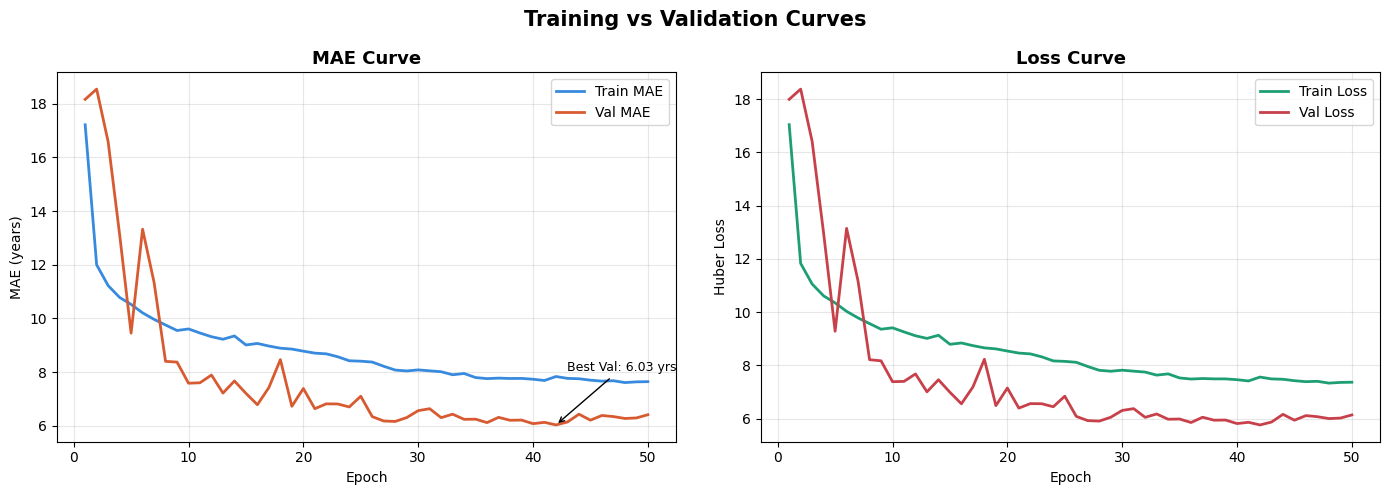

In [ ]:
# ── CURVES ───
mae_train  = history.history["mae"]
mae_val    = history.history["val_mae"]
loss_train = history.history["loss"]
loss_val   = history.history["val_loss"]
ep         = range(1, len(mae_train)+1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(ep, mae_train, "#378ADD", linewidth=2, label="Train MAE")
axes[0].plot(ep, mae_val,   "#D85A30", linewidth=2, label="Val MAE")
axes[0].set_title("MAE Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MAE (years)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate(f"Best Val: {min(mae_val):.2f} yrs",
                 xy=(np.argmin(mae_val)+1, min(mae_val)),
                 xytext=(np.argmin(mae_val)+2, min(mae_val)+2),
                 arrowprops=dict(arrowstyle="->"), fontsize=9)

axes[1].plot(ep, loss_train, "#1D9E75", linewidth=2, label="Train Loss")
axes[1].plot(ep, loss_val,   "#C7404A", linewidth=2, label="Val Loss")
axes[1].set_title("Loss Curve", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Huber Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Training vs Validation Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/curves_v3.png", dpi=150)
plt.show()



In [ ]:
# ── SUMMARY ──────────────────────────────────────────────────────
gap = min(mae_val) - min(mae_train)
print("=" * 45)
print(f"  Best Val MAE  : {min(mae_val):.2f} yrs")
print(f"  Best Train MAE: {min(mae_train):.2f} yrs")
print(f"  Overfit Gap   : {gap:.2f} yrs  {' overfitting' if gap > 4 else ' good fit'}")
print(f"  Test MAE      : {mae:.2f} yrs")
print("=" * 45)



  Best Val MAE  : 6.03 yrs
  Best Train MAE: 7.61 yrs
  Overfit Gap   : -1.58 yrs  ✅ good fit
  Test MAE      : 6.06 yrs


In [ ]:
# ── PREDICT SINGLE IMAGE ─────────────────────────────────────────
def predict_age(img_path, model, img_size=96):
    img = cv2.imread(img_path)
    if img is None: print(" Not found:", img_path); return
    rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (img_size, img_size))
    inp     = np.expand_dims(resized.astype(np.float32)/255.0, 0)
    pred    = model.predict(inp, verbose=0)[0][0]
    plt.figure(figsize=(4,4))
    plt.imshow(resized); plt.axis("off")
    plt.title(f"Predicted Age: {pred:.1f} yrs", fontsize=13)
    plt.show()
    print(f"Predicted Age: {pred:.1f} years")



In [ ]:
# Test on dataset sample
sample = os.path.join(FOLDER_PATHS[0], os.listdir(FOLDER_PATHS[0])[0])
predict_age(sample, model)

print(f"\n Model saved → {SAVE_PATH}")

NameError: name 'os' is not defined

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Model loaded!


Saving stock-photo-young-arab-man-smiling-confident-looking-to-the-side-at-street-2259338903.jpg to stock-photo-young-arab-man-smiling-confident-looking-to-the-side-at-street-2259338903.jpg


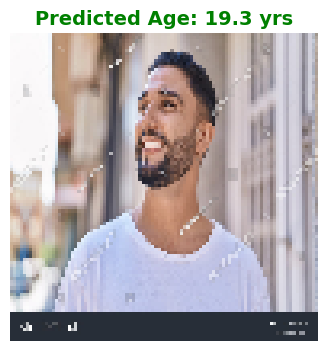

 stock-photo-young-arab-man-smiling-confident-looking-to-the-side-at-street-2259338903.jpg → Predicted Age: 19.3 years


In [ ]:

#  LOAD SAVED MODEL & PREDICT AGE ON YOUR IMAGE
import cv2, numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive, files

# ── Load Model ─────────
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/age_model_best.h5"
IMG_SIZE   = 96

model = tf.keras.models.load_model(MODEL_PATH)
print(" Model loaded!")

# ── Upload & Predict ──────
uploaded = files.upload()

for fname in uploaded.keys():
    img     = cv2.imread(fname)
    rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
    inp     = np.expand_dims(resized.astype(np.float32) / 255.0, 0)
    pred    = model.predict(inp, verbose=0)[0][0]

    plt.figure(figsize=(4, 4))
    plt.imshow(resized)
    plt.axis("off")
    plt.title(f"Predicted Age: {pred:.1f} yrs", fontsize=14,
              fontweight="bold", color="green")
    plt.show()
    print(f" {fname} → Predicted Age: {pred:.1f} years")